# Evaluation Notebook for LilyVLM (Phase 2 SFT)

This notebook evaluates your trained **LilyVLM** model on a mix of:
1. **Multimodal Reasoning Queries** (with images from `lmms-lab/multimodal-open-r1-8k-verified`).
2. **Text-Only Reasoning Queries** (from `abhinav0231/Sarvam-105b-Distill-100k`).

### Target Hardware:
Optimized to run out-of-the-box on a **Google Colab T4 GPU** (16GB VRAM) using standard `float16` precision and native Hugging Face `transformers` (no Unsloth compilation needed for evaluation).

In [1]:
# Install lightweight requirements for inference
!pip install -q transformers accelerate datasets huggingface_hub pillow

In [2]:
import os, torch, warnings
import torch.nn as nn
from transformers import AutoModel, AutoModelForCausalLM
from PIL import Image
warnings.filterwarnings("ignore")

print(f"Torch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# Colab T4 uses float16 (BF16 is not natively supported on T4)
DTYPE = torch.float16
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE} with precision: {DTYPE}")

Torch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
Using device: cuda with precision: torch.float16


In [4]:
# ==============================================================================
# Cell 2 — Authentication & Configuration Setup
# ==============================================================================
import os, torch, warnings
warnings.filterwarnings("ignore")

try:
    from huggingface_hub import login, get_token
except ImportError:
    from huggingface_hub import login, HfFolder
    get_token = HfFolder.get_token

# Retrieve HF Token
HF_TOKEN = os.environ.get("HF_TOKEN") or os.environ.get("HUGGING_FACE_HUB_TOKEN", "")
if not HF_TOKEN or HF_TOKEN == "YOUR_HF_TOKEN_HERE":
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get("HF_TOKEN") or userdata.get("HUGGINGFACE_TOKEN") or ""
    except Exception:
        pass

if not HF_TOKEN or HF_TOKEN == "YOUR_HF_TOKEN_HERE":
    cached_token = get_token()
    if cached_token:
        HF_TOKEN = cached_token

if HF_TOKEN and HF_TOKEN != "YOUR_HF_TOKEN_HERE":
    os.environ["HF_TOKEN"] = HF_TOKEN
    os.environ["HUGGING_FACE_HUB_TOKEN"] = HF_TOKEN
    try:
        login(token=HF_TOKEN, add_to_git_credential=False)
        print("✅ Authenticated with Hugging Face")
    except Exception as e:
        print(f"⚠️ Hugging Face authentication note: {e}")

# Target Repositories
HF_USERNAME = "abhinav0231"
HF_MERGED_REPO = f"{HF_USERNAME}/Lily-1.5b-v0.5-Vision-SFT"
VISION_MODEL_ID = "google/siglip2-so400m-patch14-384"
DTYPE = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16

print(f"Model ID: {HF_MERGED_REPO}")
print(f"Vision Tower: {VISION_MODEL_ID}")


>> Login successful and configurations set.


In [5]:
class LilyVLMEval(nn.Module):
    def __init__(self, vision_model_id, llm_model_id, projector_weights_path, dtype=torch.float16):
        super().__init__()
        print("Loading vision tower (SigLIP-2)...")
        self.vision_tower = AutoModel.from_pretrained(vision_model_id, torch_dtype=dtype)
        if hasattr(self.vision_tower, "vision_model"):
            self.vision_tower = self.vision_tower.vision_model

        # Freeze vision tower
        for param in self.vision_tower.parameters():
            param.requires_grad = False

        print("Loading language model (Lily LLM)...")
        self.language_model = AutoModelForCausalLM.from_pretrained(
            llm_model_id,
            torch_dtype=dtype,
            device_map="auto"
        )

        # MLP Projector mapping SigLIP-2 (1152) -> Lily LLM (1536)
        in_dim = self.vision_tower.config.hidden_size
        llm_dim = self.language_model.config.hidden_size
        self.projector = nn.Sequential(
            nn.Linear(in_dim, 2048),
            nn.SiLU(),
            nn.Linear(2048, llm_dim)
        )

        print("Loading projector weights...")
        self.projector.load_state_dict(torch.load(projector_weights_path, map_location="cpu"))

        # Move visual modules to matching device
        self.vision_tower = self.vision_tower.to(dtype=dtype, device=DEVICE)
        self.projector = self.projector.to(dtype=dtype, device=DEVICE)

        # Freeze all parameters for evaluation
        for param in self.parameters():
            param.requires_grad = False

        print("Model initialized successfully!")

    def generate(self, tokenizer, processor, prompt, image=None, max_new_tokens=512):
        if image is None:
            # Text-only fallback path
            inputs = tokenizer(prompt, return_tensors="pt").to(DEVICE)
            outputs = self.language_model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                eos_token_id=tokenizer.eos_token_id,
                pad_token_id=tokenizer.pad_token_id
            )
            gen_tokens = outputs[0][inputs.input_ids.shape[1]:]
            return tokenizer.decode(gen_tokens, skip_special_tokens=True)

        # Multimodal path: Extract visual features
        if image is not None:
            image = image.convert("RGB")
        pixel_values = processor(images=image, return_tensors="pt")["pixel_values"].to(device=DEVICE, dtype=DTYPE)

        vision_encoder = getattr(self.vision_tower, "encoder", None)
        vision_layers = getattr(vision_encoder, "layers", None)
        if vision_layers is None or len(vision_layers) < 2:
            raise RuntimeError("Could not locate SigLIP-2 encoder layers for penultimate feature extraction.")

        captured_features = []
        def capture_penultimate_layer(_module, _inputs, output):
            # Some Transformers releases return a tensor; others return a tuple.
            captured_features.append(output[0] if isinstance(output, (tuple, list)) else output)

        hook = vision_layers[-2].register_forward_hook(capture_penultimate_layer)
        try:
            with torch.no_grad():
                self.vision_tower(pixel_values, return_dict=True)
        finally:
            hook.remove()

        if len(captured_features) != 1 or not isinstance(captured_features[0], torch.Tensor):
            raise RuntimeError("Failed to capture SigLIP-2's penultimate encoder layer.")
        image_features = captured_features[0]  # [1, 729, 1152], full 27x27 grid

        # Direct projection of 729 visual tokens (no 2D spatial downsampling)
        with torch.no_grad():
            image_embeddings = self.projector(image_features)  # Shape: [1, 729, 1536]

        # Tokenize and embed text prompt
        inputs = tokenizer(prompt, return_tensors="pt").to(DEVICE)
        input_ids = inputs.input_ids
        attention_mask = inputs.attention_mask

        text_embeddings = self.language_model.get_input_embeddings()(input_ids)

        # Inject visual embeddings at the "<image>" token position
        image_token_id = tokenizer.convert_tokens_to_ids("<image>")
        image_pos = (input_ids[0] == image_token_id).nonzero(as_tuple=True)[0]

        if len(image_pos) == 0:
            embeddings = text_embeddings
        else:
            idx = image_pos[0].item()
            left_embeds = text_embeddings[:, :idx, :]
            right_embeds = text_embeddings[:, idx+1:, :]
            embeddings = torch.cat([left_embeds, image_embeddings, right_embeds], dim=1)

            visual_mask = torch.ones((1, image_embeddings.shape[1]), dtype=attention_mask.dtype, device=attention_mask.device)
            left_mask = attention_mask[:, :idx]
            right_mask = attention_mask[:, idx+1:]
            attention_mask = torch.cat([left_mask, visual_mask, right_mask], dim=1)

        # Run auto-regressive generation
        outputs = self.language_model.generate(
            inputs_embeds=embeddings,
            attention_mask=attention_mask,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.pad_token_id
        )
        return tokenizer.decode(outputs[0], skip_special_tokens=True)


In [6]:
from huggingface_hub import hf_hub_download
from transformers import AutoTokenizer, AutoProcessor

# Download tokenizer, processor and base language model
print(">> Downloading tokenizer & processor...")
tokenizer = AutoTokenizer.from_pretrained(HF_MERGED_REPO)
processor = AutoProcessor.from_pretrained(VISION_MODEL_ID)

# Add special token <image> if not present (safeguard)
if "<image>" not in tokenizer.get_vocab():
    tokenizer.add_tokens(["<image>"], special_tokens=True)

if tokenizer.pad_token_id is None:
    tokenizer.pad_token_id = tokenizer.eos_token_id

# Download the projector weights file (force_download=True to invalidate cache)
print(">> Downloading latest projector weights...")
projector_weights_path = hf_hub_download(
    repo_id=HF_MERGED_REPO,
    filename="mm_projector_final.bin",
    token=HF_TOKEN,
    force_download=True
)

# Instantiate our evaluation model wrapper
model = LilyVLMEval(
    vision_model_id=VISION_MODEL_ID,
    llm_model_id=HF_MERGED_REPO,
    projector_weights_path=projector_weights_path,
    dtype=DTYPE
)


>> Downloading tokenizer & processor...


config.json:   0%|          | 0.00/1.43k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/375 [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 11.4MB            

tokenizer.json: downloading bytes:           |  0.00B            

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 3.09GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/164 [00:00<?, ?B/s]

Loading projector weights...
Model initialized successfully!


In [7]:
from datasets import load_dataset
from IPython.display import display

print(">> Loading multimodal evaluation data from HF Hub: abhinav0231/Lily-Vision-SFT-Dataset...")
ds_sft = load_dataset('abhinav0231/Lily-Vision-SFT-Dataset', split='train', streaming=True)

multimodal_queries = []
for item in ds_sft:
    prompt = item['prompt']
    if "<image>" in prompt and item.get('image') is not None:
        # Extract problem text from the prompt
        problem_text = prompt.split("<image>")[-1].split("<|im_end|>")[0].strip()
        multimodal_queries.append({
            "id": len(multimodal_queries) + 1,
            "image": item['image'],
            "prompt": prompt,
            "problem": problem_text if problem_text else prompt,
            "ground_truth": item['response']
        })
        if len(multimodal_queries) >= 5:
            break

print(f"Loaded {len(multimodal_queries)} multimodal queries successfully!")

>> Loading multimodal evaluation data from HF Hub: abhinav0231/Lily-Vision-SFT-Dataset...


README.md:   0%|          | 0.00/363 [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/58 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/58 [00:00<?, ?it/s]

Loaded 5 multimodal queries successfully!



MULTIMODAL QUERY #1


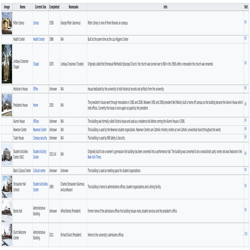


Question: name a building that was previously a residence hall?

Generating model reasoning and answer...


[transformers] Both `max_new_tokens` (=1536) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



--- MODEL OUTPUT ---
<think>
The text mentions that the building formerly known as the "Old Residence Hall" was built in 1962 and is located on the campus of the University of Notre Dame. It is currently used as a residence hall for students.
</think>
<answer>
Old Residence Hall
</answer>

--- EXPECTED GROUND TRUTH ---
<think>
Victoria House was previously a residence hall before becoming the Alumni House in 2006. It now houses offices for alumni-related activities.
</think>
<answer>
Victoria House/Alumni House. 
</answer>

MULTIMODAL QUERY #2


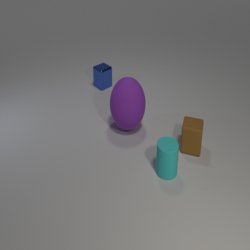

[transformers] Both `max_new_tokens` (=1536) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Question: Subtract all cylinders. How many objects are left?

Generating model reasoning and answer...

--- MODEL OUTPUT ---
<think>
Step 1: The image shows several objects: a sphere, a cube, a cylinder, and a cube. We need to identify and count these objects.

Step 2: The sphere is one object. The cube is another object. The cylinder is a third object. The last object is also a cube.

Step 3: To find out how many objects are left after subtracting the cylinders, we need to count the remaining objects: sphere, cube, and cube.

Step 4: Count the remaining objects: there are 3 objects left after removing the cylinders.
</think>
<answer>
3
</answer>

--- EXPECTED GROUND TRUTH ---
<think>
Step 1: The task is to count the number of objects remaining after subtracting all cylinders from the image.

Step 2: The image contains several 3D objects: a purple sphere, a blue cube, a brown cube, and a teal cylinder.

Step 3: Identify which objects are cylinders to subtract them from the total count

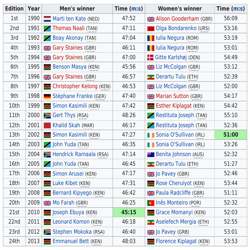

[transformers] Both `max_new_tokens` (=1536) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Question: how long did sonia o'sullivan take to finish in 2003?

Generating model reasoning and answer...

--- MODEL OUTPUT ---
<think>
Sonia O'Sullivan finished in 2003 with a time of 58.00 seconds, which is the 10th fastest time in the list of women's winners. She was from Ireland and won the event with a time of 58.00 seconds.
</think>
<answer>
Sonia O'Sullivan took 58.00 seconds to finish in 2003.
</answer>

--- EXPECTED GROUND TRUTH ---
<think>
Answer 2: Sonia O'Sullivan finished in 53 minutes and 26 seconds in 2003, winning the women's category of the 14th edition of the race.
</think>
<answer>
Answer 1: 53:26
</answer>

MULTIMODAL QUERY #4


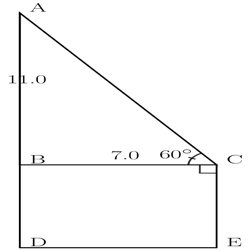

[transformers] Both `max_new_tokens` (=1536) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Question: What is the length of AC in the right triangle ABC?
Choices:
A. 13.0;
B. 12.5;
C. 13.5;
D. 14.0

Generating model reasoning and answer...

--- MODEL OUTPUT ---
<think>
Step 1: Identify the given information from the image. The triangle ABC is a right triangle with a right angle at C. The side AC is labeled as 11.0 units, and the side BC is labeled as 7.0 units.

Step 2: Recognize that in a right triangle, the Pythagorean theorem can be used to find the length of the hypotenuse. The Pythagorean theorem states that for a right triangle with legs a and b, and hypotenuse c, the relationship is \(a^2 + b^2 = c^2\).

Step 3: Apply the Pythagorean theorem to triangle ABC. Here, \(a = 11.0\) units and \(b = 7.0\) units. Substitute these values into the equation:
\[11.0^2 + 7.0^2 = c^2\]

Step 4: Calculate the squares of the legs:
\[11.0^2 = 121.0\]
\[7.0^2 = 49.0\]

Step 5: Add the squares of the legs:
\[121.0 + 49.0 = 170.0\]

Step 6: Take the square root of the sum to find the hyp

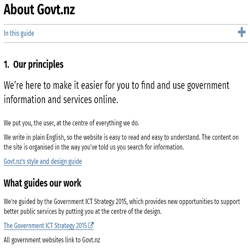

[transformers] Both `max_new_tokens` (=1536) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Question: What strategic document guides the work of the Govt.nz website?

Generating model reasoning and answer...

--- MODEL OUTPUT ---
<think>
The Govt.nz website is guided by the Government ICT Strategy 2015, which provides new opportunities to support better public services by putting users at the centre of the design process. This strategy outlines the key principles and goals for the website, including making it easy for users to find and use government information and services online. The strategy also includes specific actions and milestones for the website to achieve its goals, such as improving the user experience, enhancing accessibility, and ensuring that the content is relevant and useful for the target audience.
</think>
<answer>
Government ICT Strategy 2015
</answer>

--- EXPECTED GROUND TRUTH ---
<think>
According to the text, the Government ICT Strategy 2015 is the strategic document that guides the work of the Govt.nz website. This strategy aims to provide better pu

In [8]:
for q in multimodal_queries:
    print("\n" + "="*80)
    print(f"MULTIMODAL QUERY #{q['id']}")
    print("="*80)

    # Display the input image
    display(q['image'].resize((250, 250)))
    print(f"\nQuestion: {q['problem']}\n")

    # Generate response
    print("Generating model reasoning and answer...")
    response = model.generate(tokenizer, processor, q['prompt'], q['image'], max_new_tokens=1536)

    print("\n--- MODEL OUTPUT ---")
    print(response)

    print("\n--- EXPECTED GROUND TRUTH ---")
    print(q['ground_truth'])

In [9]:
print(">> Loading text-only reasoning evaluation data from HF Hub: abhinav0231/Lily-Vision-SFT-Dataset...")
ds_sft = load_dataset('abhinav0231/Lily-Vision-SFT-Dataset', split='train', streaming=True)

text_queries = []
for item in ds_sft:
    prompt = item['prompt']
    if "<image>" not in prompt:
        question_text = prompt.split("<|im_start|>user")[-1].split("<|im_end|>")[0].strip()
        text_queries.append({
            "id": len(text_queries) + 1,
            "prompt": prompt,
            "question": question_text if question_text else prompt,
            "ground_truth_answer": item['response']
        })
        if len(text_queries) >= 5:
            break

print(f"Loaded {len(text_queries)} text reasoning queries successfully!")

>> Loading text-only reasoning evaluation data from HF Hub: abhinav0231/Lily-Vision-SFT-Dataset...


Resolving data files:   0%|          | 0/58 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/58 [00:00<?, ?it/s]

Loaded 5 text reasoning queries successfully!


In [10]:
for q in text_queries:
    print("\n" + "="*80)
    print(f"TEXT QUERY #{q['id']}")
    print("="*80)
    print(f"Question: {q['question']}\n")

    # Generate response (passing image=None)
    print("Generating model reasoning and answer...")
    response = model.generate(tokenizer, processor, q['prompt'], image=None, max_new_tokens=1536)

    print("\n--- MODEL OUTPUT ---")
    print(response)

    print("\n--- EXPECTED GROUND TRUTH ---")
    print(q['ground_truth_answer'])

[transformers] Both `max_new_tokens` (=1536) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



TEXT QUERY #1
Question: A trainee at the Infosys training center is struggling with a SQL query function meant to aggregate quarterly revenue because it ignores the last fiscal month. Write the corrected function and explain the fix using a financial analogy about quarterly earnings reports in under 150 words.

Generating model reasoning and answer...


[transformers] Both `max_new_tokens` (=1536) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



--- MODEL OUTPUT ---
<think>
The user is asking for a SQL function that aggregates quarterly revenue, but there's a problem with it ignoring the last fiscal month. I need to:
1. Write a corrected SQL function
2. Explain the fix using a financial analogy about quarterly earnings reports
3. Keep it under 150 words

Let me think about the SQL function first:
- The issue is likely that the function is aggregating all months except the last one
- For quarterly revenue, we typically want to include all quarters, not just the first three
- The function might be using a window function or a subquery that's filtering out the last quarter

For the financial analogy, I'll use quarterly earnings reports:
- Quarterly earnings reports typically show revenue for Q1, Q2, Q3, and Q4
- The last quarter (Q4) is the most important for financial reporting
- The function should include Q4 revenue
- The function should be able to handle any number of quarters

Let me write the SQL function and then the fina

[transformers] Both `max_new_tokens` (=1536) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



--- MODEL OUTPUT ---
<think>
The user is asking for a strategic plan for Infosys R&D team to structure quantum software efforts for global market leadership. This is a complex business strategy question that requires:

1. Understanding Infosys's current position in the market
2. Understanding quantum computing and its applications
3. Developing a strategic framework
4. Benchmarking against industry norms
5. Identifying three priority investment areas

Let me think through this systematically:

## Infosys's Current Position
- Infosys is a global IT services and consulting giant
- They have been investing in AI and cloud services
- They have a strong R&D culture
- They have partnerships with major quantum computing companies

## Quantum Computing Basics
- Quantum computing is fundamentally different from classical computing
- Uses quantum bits (qubits) that can be both 0 and 1 simultaneously
- Has exponential speedup potential for certain problems
- Applications: cryptography, optimizat

[transformers] Both `max_new_tokens` (=1536) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



--- MODEL OUTPUT ---
<think>
The user is asking about a BSE energy stock price calculation using algebraic inverse operations versus a guess-and-check approach. Let me break this down:

The equation given is: 10x + 2000 = 7000

We need to explain why solving using algebraic inverse operations is more reliable than guess-and-check for determining the share price in Indian Rupees.

Let me think through this step by step:

1. First, I need to understand what the equation represents:
   - 10x represents the price of the stock in Rupees
   - 2000 is the fixed cost (like a base price or commission)
   - 7000 is the total price

2. The algebraic inverse operation approach:
   - We need to isolate x
   - Subtract 2000 from both sides: 10x = 7000 - 2000
   - Simplify: 10x = 5000
   - Divide both sides by 10: x = 5000 / 10
   - x = 500

3. The guess-and-check approach:
   - Start with a guess: Let's try x = 500
   - Check: 10(500) + 2000 = 5000 + 2000 = 7000 ✓
   - This works, but it's not syst

[transformers] Both `max_new_tokens` (=1536) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



--- MODEL OUTPUT ---
<think>
The user is asking for unit test strategies to detect security vulnerabilities in a database interaction layer after refactoring for RBI data localization and security requirements. This is a technical question about software testing and security testing.

Let me think through this systematically:

1. First, I need to understand what the refactoring did - I'll need to hypothesize what the refactoring might have done, but I should be careful not to make assumptions about specific details.

2. Then I need to identify potential security vulnerabilities that could arise from database interactions, especially in a banking context.

3. Finally, I need to propose three unit test strategies that would detect these vulnerabilities.

Let me structure my response:

1. First, I'll hypothesize what the refactoring might have done (though I should be careful not to make specific claims about exact refactoring details)
2. Then identify potential security vulnerabilities


## Cell 10 — Interactive Custom Prompt & Image Inference
Run custom inference by uploading an image (optional) and entering a prompt.
- **With Image**: Upload an image file (`.png`, `.jpg`, `.jpeg`), and ask any visual/multimodal reasoning question.
- **Text-Only**: Skip image upload (or leave image path empty) and ask any text-based question.

In [ ]:
from PIL import Image
import io
from IPython.display import display

def run_custom_inference(image=None, prompt_text=""):
    if not prompt_text.strip():
        print("⚠️ Prompt text is empty!")
        return

    # Format prompt in ChatML template
    system_prompt = "You are a precise, helpful assistant. Always reason step by step inside <think> tags, then write your final answer inside <answer> tags."
    if image is not None:
        formatted_prompt = f"<|im_start|>system\n{system_prompt}<|im_end|>\n<|im_start|>user\n<image>\n{prompt_text}<|im_end|>\n<|im_start|>assistant\n"
    else:
        formatted_prompt = f"<|im_start|>system\n{system_prompt}<|im_end|>\n<|im_start|>user\n{prompt_text}<|im_end|>\n<|im_start|>assistant\n"

    print("\n" + "="*80)
    print("CUSTOM INFERENCE RUN")
    print("="*80)
    if image is not None:
        display(image.resize((250, 250)))
        print(f"Mode     : Multimodal (Image + Text)")
    else:
        print(f"Mode     : Text-Only")
    print(f"Prompt   : {prompt_text}\n")

    print("Generating model response...")
    response = model.generate(tokenizer, processor, formatted_prompt, image=image, max_new_tokens=1536)
    print("\n--- MODEL OUTPUT ---")
    print(response)
    return response

# --- Interactive Upload & Input Helper ---
print("Choose input mode:")
print("1. Upload Image + Enter Prompt")
print("2. Text-Only Prompt (No Image)")

mode = input("Enter mode (1 or 2): ").strip()

user_image = None
if mode == "1":
    try:
        from google.colab import files
        print("Please select an image file to upload:")
        uploaded = files.upload()
        if uploaded:
            filename = list(uploaded.keys())[0]
            user_image = Image.open(io.BytesIO(uploaded[filename]))
            print(f"✅ Successfully loaded uploaded image: {filename}")
    except Exception as e:
        print(f"Colab upload not active or cancelled: {e}")
        local_img_path = input("Enter local image file path (or press Enter to skip image): ").strip()
        if local_img_path and os.path.exists(local_img_path):
            user_image = Image.open(local_img_path)
            print(f"✅ Successfully loaded image from path: {local_img_path}")

user_prompt = input("\nEnter your question / prompt: ").strip()
if user_prompt:
    run_custom_inference(image=user_image, prompt_text=user_prompt)
else:
    print("No prompt provided. You can also call `run_custom_inference(image, prompt)` directly!")
